In [ ]:
!nvidia-smi
import torch
print("GPU:", torch.cuda.get_device_name(0))
print("SM:", torch.cuda.get_device_capability(0))

Tue Mar 24 04:34:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             49W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
!unzip gemm-tensorcore-benchmark.zip
%cd gemm-tensorcore-benchmark

Archive:  gemm-tensorcore-benchmark.zip
   creating: gemm-tensorcore-benchmark/
  inflating: gemm-tensorcore-benchmark/requirements.txt  
  inflating: gemm-tensorcore-benchmark/benchmark_pytorch.py  
  inflating: gemm-tensorcore-benchmark/Makefile  
  inflating: gemm-tensorcore-benchmark/run_all.sh  
  inflating: gemm-tensorcore-benchmark/benchmark_cublas.cu  
  inflating: gemm-tensorcore-benchmark/README.md  
  inflating: gemm-tensorcore-benchmark/_test_pytorch.json  
  inflating: gemm-tensorcore-benchmark/_test_cublas.csv  
  inflating: gemm-tensorcore-benchmark/plot_results.py  
/content/gemm-tensorcore-benchmark


In [ ]:
!pip install numpy pandas matplotlib
import torch
print(torch.__version__, torch.version.cuda)  # PyTorch already pre-installed in Colab

2.10.0+cu128 12.8


In [ ]:
!python benchmark_pytorch.py --warmup 20 --iters 100

  PyTorch FC-Layer GEMM Benchmark  –  CUDA Core FP32 vs Tensor Core TF32
  GPU            : NVIDIA A100-SXM4-40GB  (SM 80)
  PyTorch        : 2.10.0+cu128
  CUDA           : 12.8
  Warm-up iters  : 20
  Bench iters    : 100

Mode                       Batch   InFeat  OutFeat    Latency(ms)     TFLOPS
----------------------------------------------------------------------------
CUDA Core (FP32)              64     1024     1024         0.0277      4.849
Tensor Core (TF32)            64     1024     1024         0.0296      4.539
CUDA Core (FP32)              64     2048     2048         0.0503     10.671
Tensor Core (TF32)            64     2048     2048         0.0288     18.612
CUDA Core (FP32)              64     4096     4096         0.1590     13.505
Tensor Core (TF32)            64     4096     4096         0.0754     28.498
CUDA Core (FP32)             128     1024     1024         0.0395      6.797
Tensor Core (TF32)           128     1024     1024         0.0286      9.379
CUDA 

In [ ]:
!nvcc -O3 -arch=sm_80 -std=c++17 -o benchmark_cublas benchmark_cublas.cu -lcublas
!./benchmark_cublas

  cuBLAS GEMM Benchmark  –  CUDA Core FP32 vs Tensor Core TF32
  GPU   : NVIDIA A100-SXM4-40GB  (SM 80)
  CUDA  : 12.8
  Warm-up: 20   Iters: 100

Mode                         Batch   InFeat  OutFeat    Latency(ms)     TFLOPS
-----------------------------------------------------------------------------------------
CUDA Core (FP32)                64     1024     1024         0.0246      5.452
Tensor Core (TF32)              64     1024     1024         0.0151      8.904
CUDA Core (FP32)                64     2048     2048         0.0564      9.519
Tensor Core (TF32)              64     2048     2048         0.0264     20.345
CUDA Core (FP32)                64     4096     4096         0.1835     11.702
Tensor Core (TF32)              64     4096     4096         0.0817     26.277
CUDA Core (FP32)               128     1024     1024         0.0394      6.809
Tensor Core (TF32)             128     1024     1024         0.0177     15.206
CUDA Core (FP32)               128     2048     2048

In [ ]:
import subprocess
gpu = subprocess.check_output(
    "nvidia-smi --query-gpu=name --format=csv,noheader", shell=True
).decode().strip()
!python plot_results.py --gpu "{gpu}" --outdir plots/

  Loaded PyTorch results : 22 rows  (pytorch_results.json)
  Loaded cuBLAS results  : 22 rows  (cublas_results.csv)

  PyTorch Speedup Statistics
  ────────────────────────────────────────
  Mean speedup  : 3.29×
  Max  speedup  : 6.91×  (B=1024, 4K×4K)
  Min  speedup  : 0.94×
  Peak TC TFLOPS: 122.75
  Peak FP32 TFLOPS: 17.76

  cuBLAS Speedup Statistics
  ────────────────────────────────────────
  Mean speedup  : 3.34×
  Max  speedup  : 6.00×  (B=1024, 4K×4K)
  Min  speedup  : 1.63×
  Peak TC TFLOPS: 110.69
  Peak FP32 TFLOPS: 18.45

  Plots saved:
    plots/plot_latency_tflops.png
    plots/plot_speedup.png
    plots/plot_tflops_vs_size.png
    plots/plot_throughput_all.png



plots/plot_latency_tflops.png


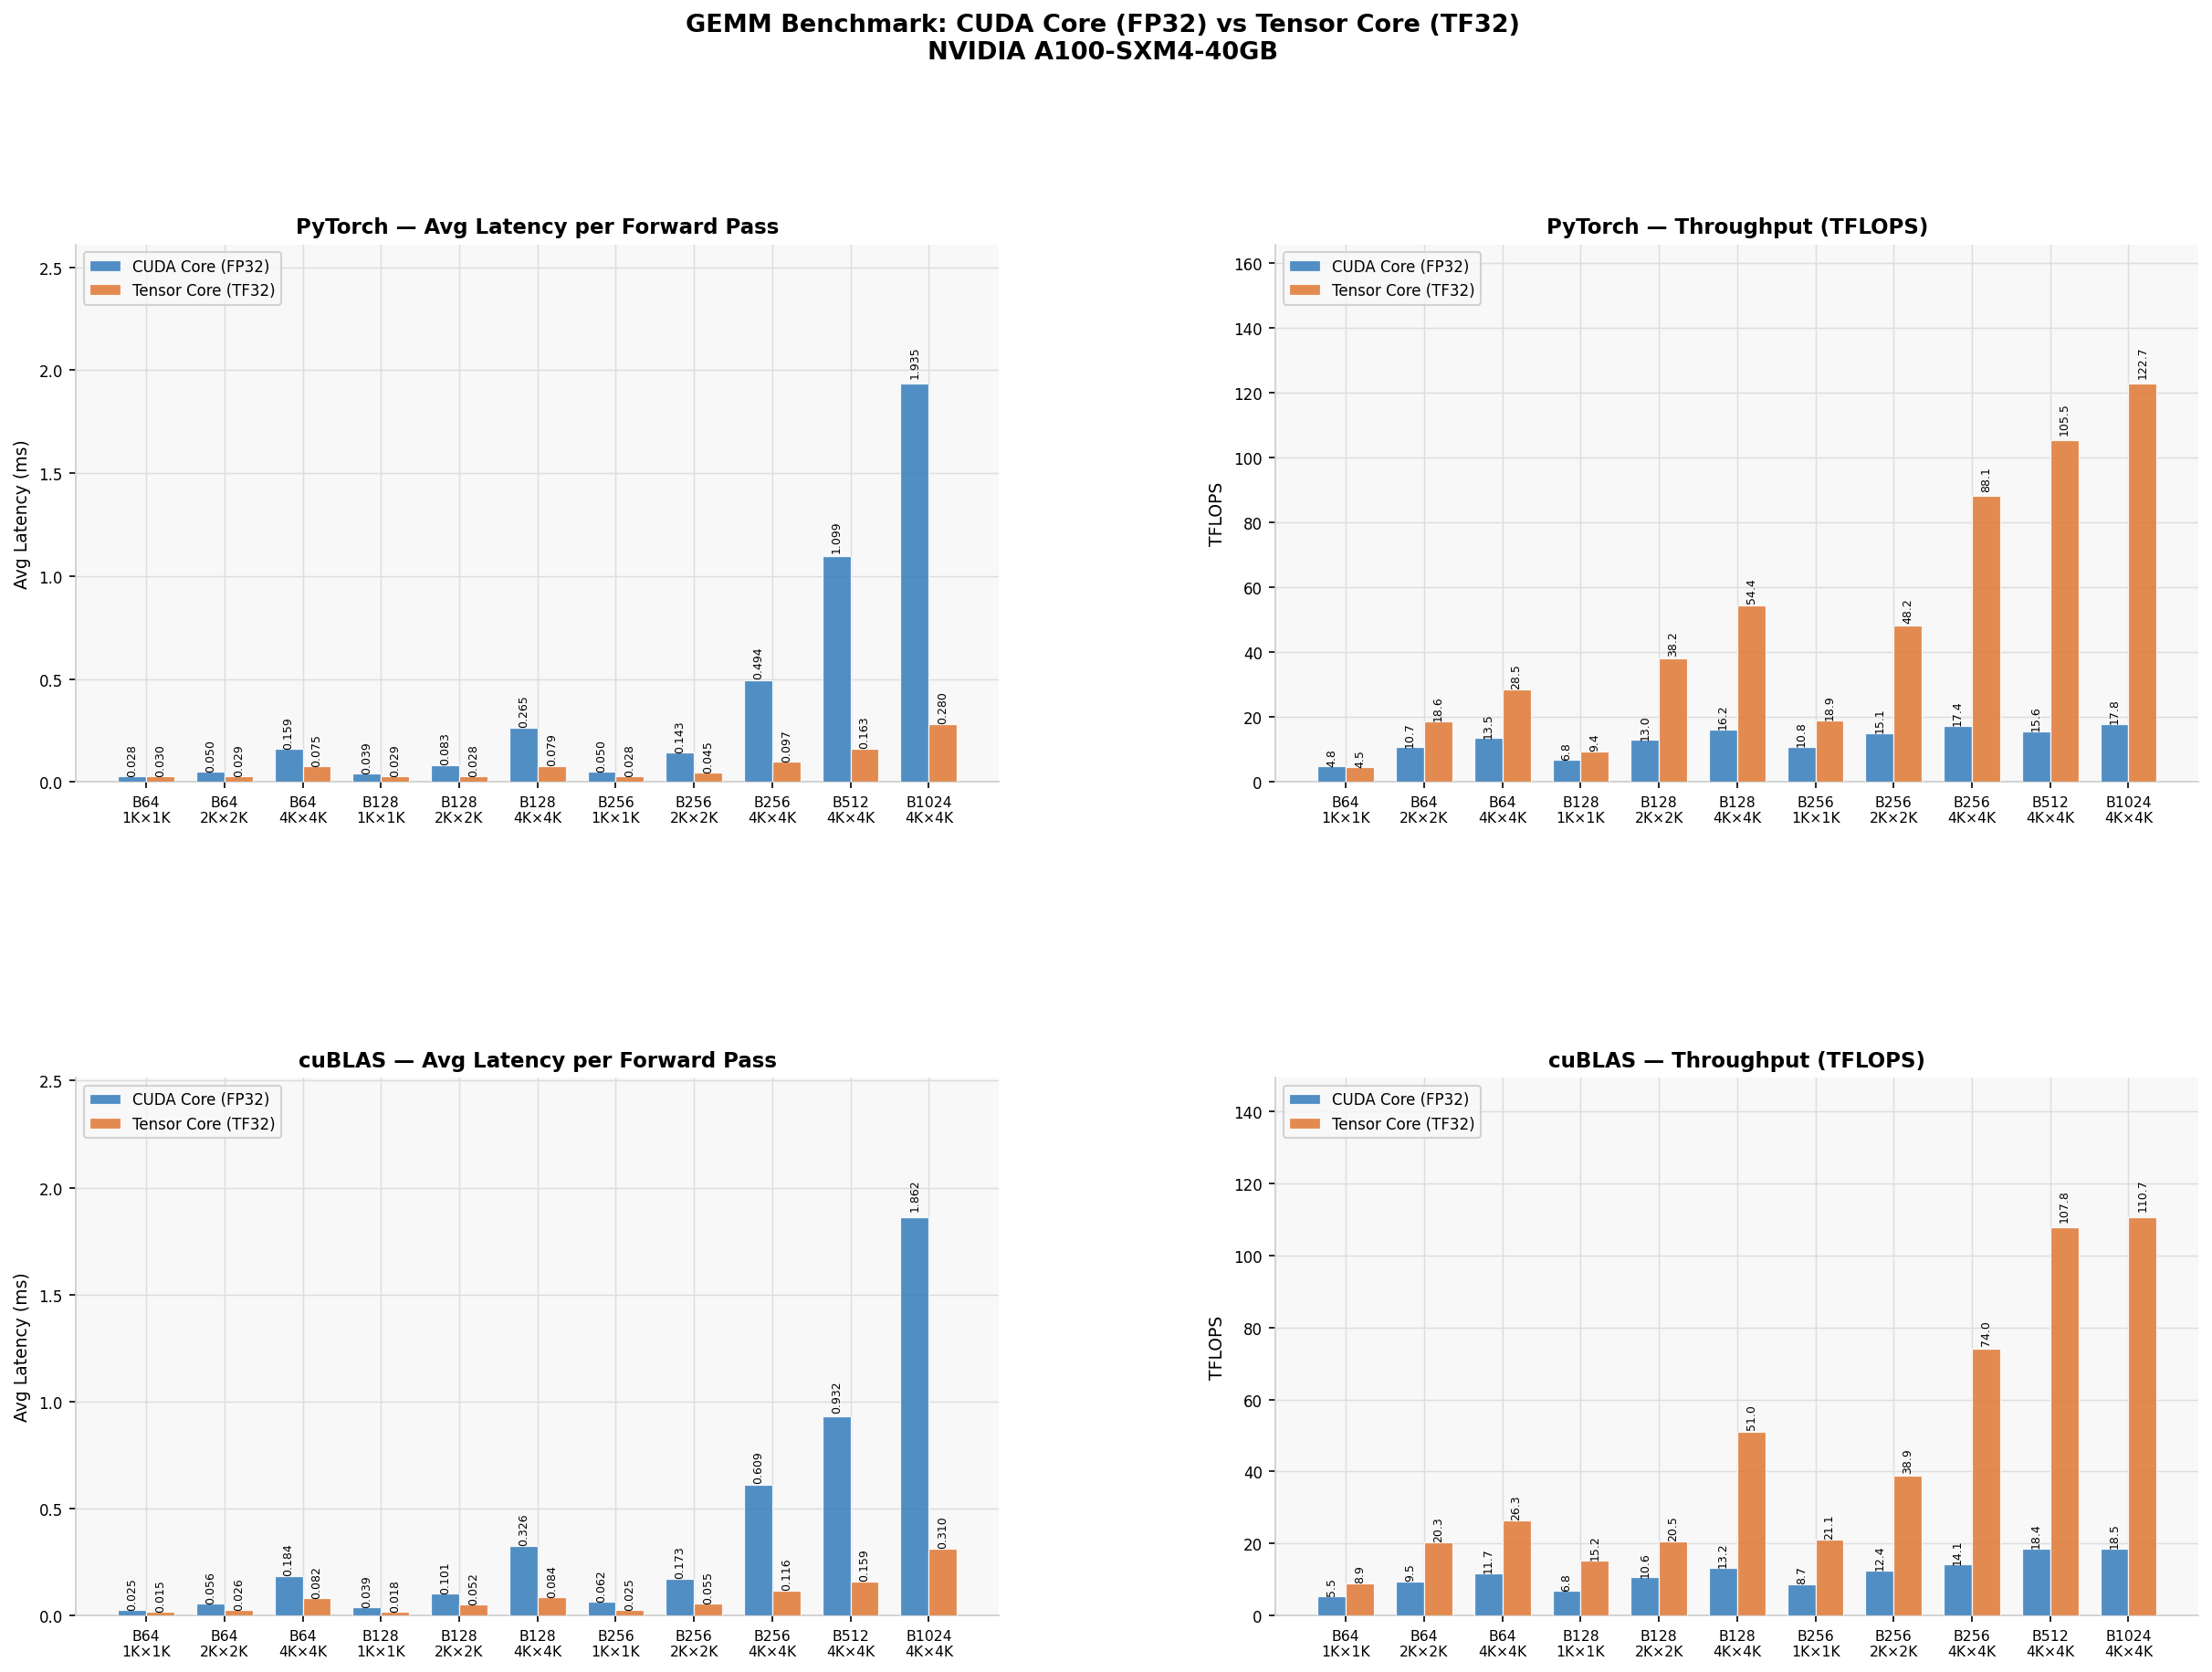

plots/plot_speedup.png


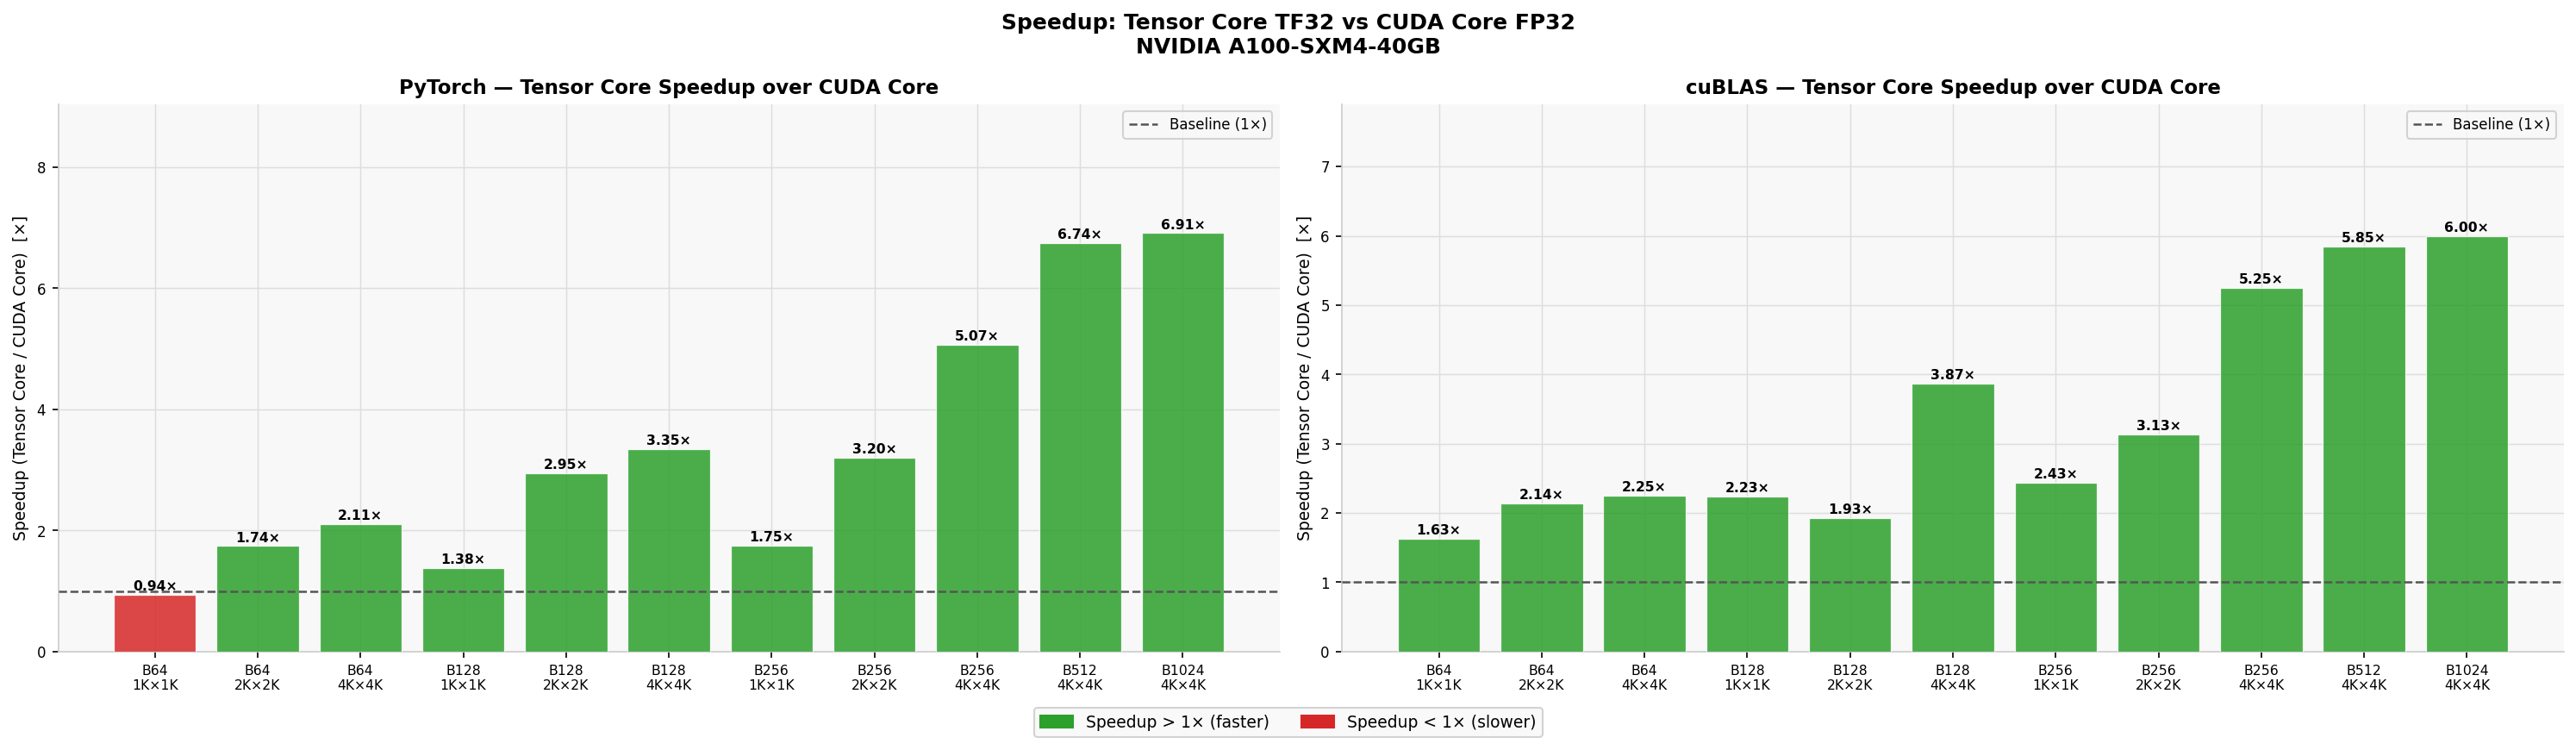

plots/plot_tflops_vs_size.png


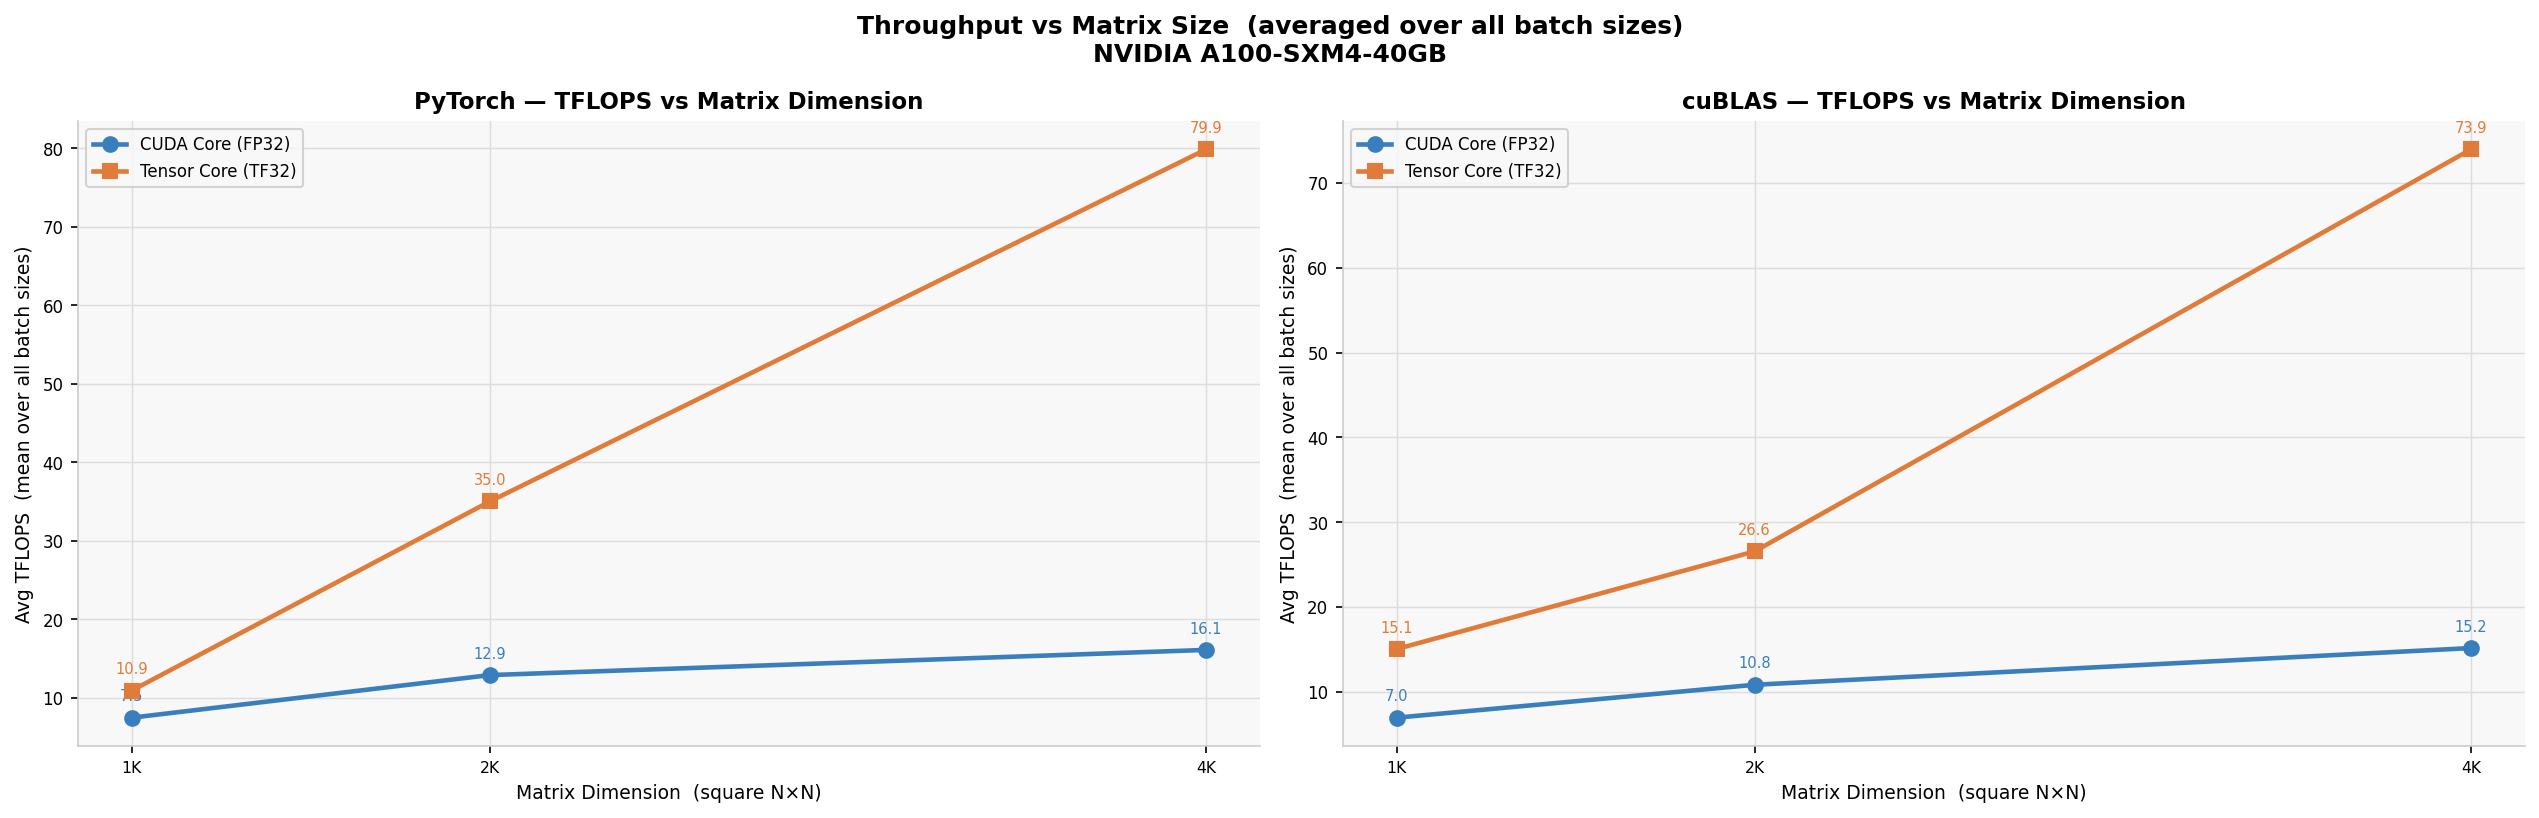

plots/plot_throughput_all.png


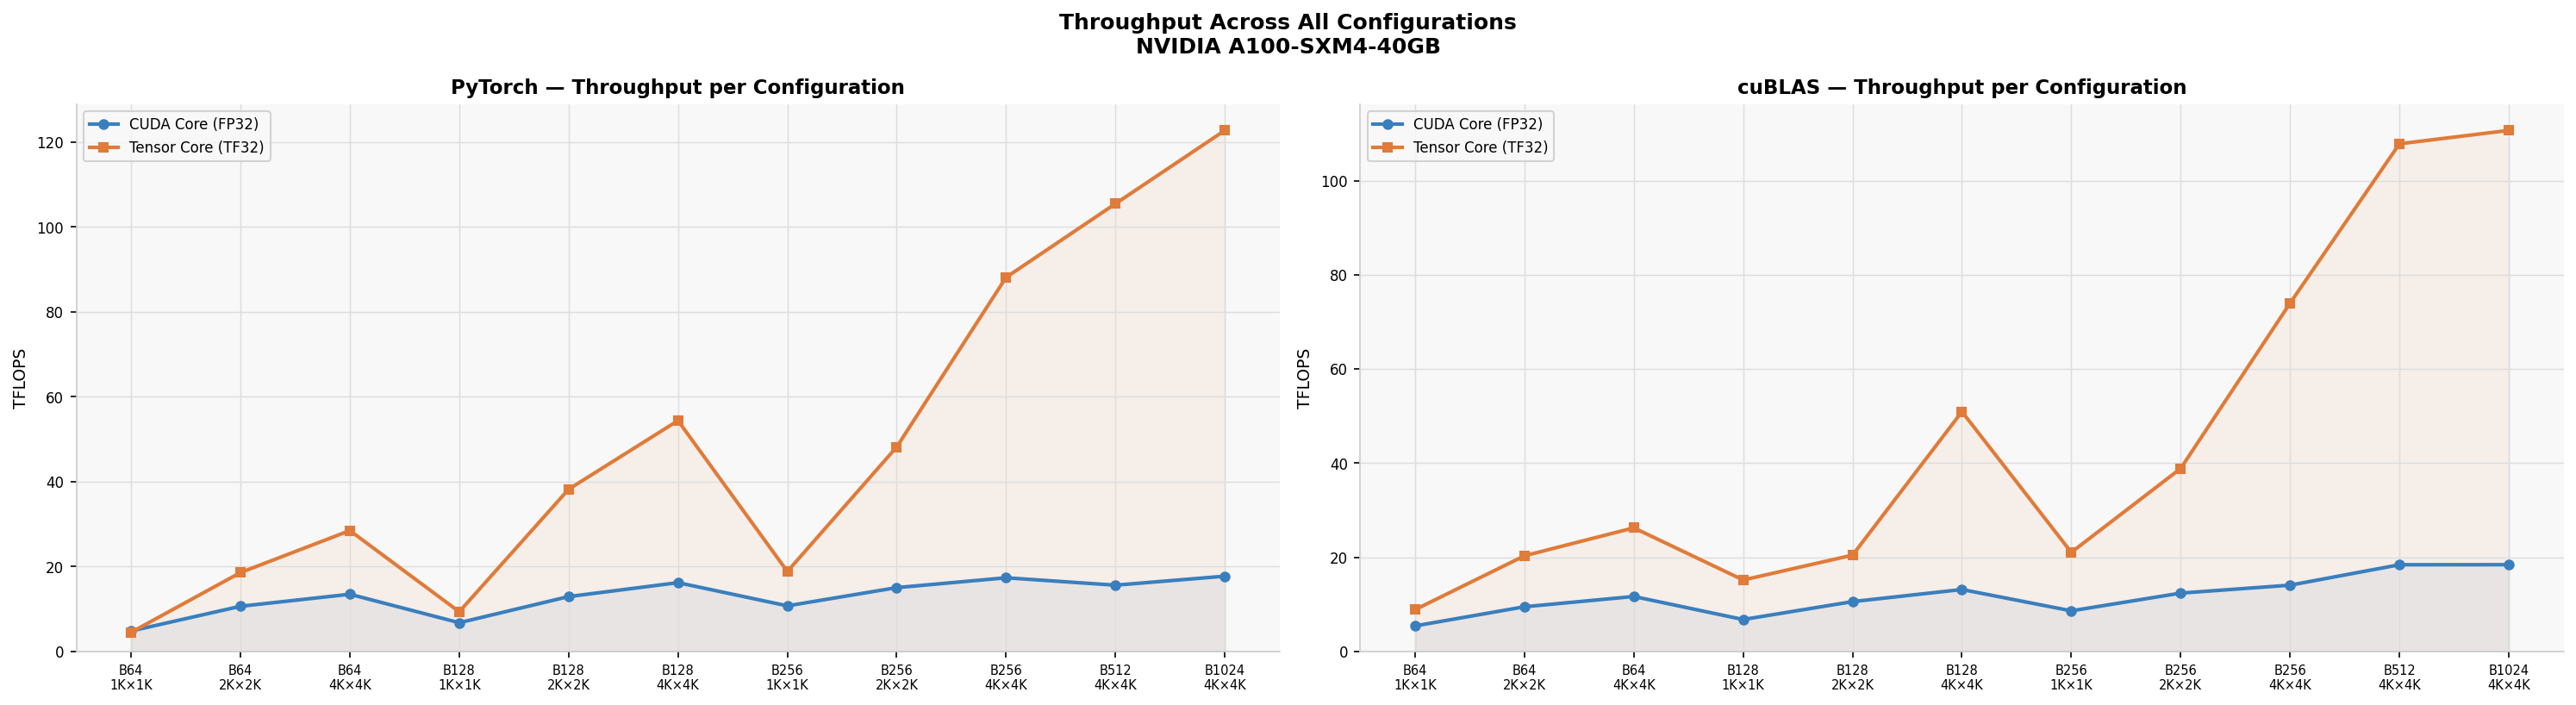

In [ ]:
from IPython.display import Image, display
import glob
for f in sorted(glob.glob("plots/plot_*.png")):
    print(f)
    display(Image(f))

In [ ]:
import json
with open("pytorch_results.json") as f:
    results = json.load(f)
for b, k, n in [(64,1024,1024),(1024,4096,4096)]:
    cuda = next(r for r in results if r["batch_size"]==b and r["in_features"]==k and not r["use_tf32"])
    tc   = next(r for r in results if r["batch_size"]==b and r["in_features"]==k and r["use_tf32"])
    print(f"B={b} {k}x{n}  speedup={cuda['latency_ms']/tc['latency_ms']:.2f}x")

B=64 1024x1024  speedup=0.94x
B=1024 4096x4096  speedup=6.91x


In [ ]:
import torch, torch.nn as nn
torch.manual_seed(42)
layer = nn.Linear(4096, 4096, bias=False).cuda().float()
x = torch.randn(256, 4096, device="cuda")
torch.backends.cuda.matmul.allow_tf32 = False
out_fp32 = layer(x).clone()
torch.backends.cuda.matmul.allow_tf32 = True
out_tf32 = layer(x).clone()
rel = (out_fp32 - out_tf32).abs().max() / out_fp32.abs().max() * 100
print(f"Relative diff: {rel.item():.4f}%")
# Ampere: 0.001–0.1% → TF32 active
# Pre-Ampere: 0.000% → TF32 not used

Relative diff: 0.0259%


In [ ]:
import json
with open("pytorch_results.json") as f: results = json.load(f)
fails = [r for r in results
         if abs(r["latency_ms"]*1e-3*r["tflops"]*1e12 - 2*r["batch_size"]*r["in_features"]*r["out_features"])
         / (2*r["batch_size"]*r["in_features"]*r["out_features"]) > 0.001]
print("ALL PASS" if not fails else f"FAILED: {len(fails)} rows")

ALL PASS
